# setup_and_data_generation

In [1]:
# !pip install stable-baselines3 shimmy gymnasium pandas numpy matplotlib
import gymnasium as gym
from gymnasium import spaces
import pandas as pd
import numpy as np
import os
import yfinance as yf
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_checker import check_env
from rl_system import *

In [2]:
# --- Configuration ---
WINDOW_SIZE = 60       
RISK_AVERSION = 4.0
TX_COST_BPS = 0.0010   
REBALANCE_THRESHOLD = 0.05 

def load_real_data(tickers=None, benchmark='QQQ', start='2015-01-01', end='2025-10-31'):
    """
    Robust loader for Yahoo Finance data.
    Fixes: Timezones, Missing Values (FFILL), and MultiIndex formatting.
    """
    if tickers is None:
        # Tech heavy portfolio
        tickers = ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG']
    
    # Download everything at once
    all_tickers = tickers + [benchmark]
    print(f"Downloading {len(all_tickers)} assets...")
    
    # auto_adjust=True gives us 'Close' adjusted for splits/dividends
    raw_data = yf.download(all_tickers, start=start, end=end, progress=False, auto_adjust=True)
    
    # 1. Handle YFinance MultiIndex (Price Type, Ticker)
    # The columns usually look like ('Close', 'AAPL'). We just want the 'Close' slice.
    if isinstance(raw_data.columns, pd.MultiIndex):
        try:
            # Try grabbing the 'Close' cross-section directly
            df = raw_data['Close'].copy()
        except KeyError:
            # Fallback if yfinance changes format or case
            df = raw_data['close'].copy()
    else:
        df = raw_data.copy()

    # 2. Rename Benchmark to 'SPY' 
    # (The Environment expects a column named 'SPY' for the market regime logic)
    if benchmark in df.columns:
        df = df.rename(columns={benchmark: 'SPY'})
    
    # 3. Data Cleaning (Crucial for RL)
    # Forward Fill first (carry forward yesterday's price to fill holidays)
    df = df.ffill()
    # Then drop any remaining NaNs (usually the first few days if data starts at different times)
    df = df.dropna().round(2)
    
    # 4. Strip Timezone (Make it naive)
    df.index = df.index.tz_localize(None)
    
    # 5. Reorder: Assets first, Benchmark last
    # This ensures the matrix slicing in the Env works as expected
    asset_cols = [t for t in tickers if t in df.columns]
    final_cols = asset_cols + ['SPY']
    
    # Verify we didn't lose the benchmark
    if 'SPY' not in df.columns:
        raise ValueError("Benchmark failed to download or rename!")
        
    return df[final_cols]

# Load and Verify

df_full = load_real_data()
print(f"Data Successfully Loaded: {df_full.shape}")
print(f"Date Range: {df_full.index.min()} to {df_full.index.max()}")
print("Sample:")
df_full.tail()


Data Successfully Loaded: (2724, 8)
Date Range: 2015-01-02 00:00:00 to 2025-10-30 00:00:00
Sample:


Ticker,NVDA,MU,AAPL,AMD,ASML,MSFT,GOOG,SPY
Date,,,,,,,,
2025-10-24,186.25,219.02,262.57,252.92,1031.27,522.63,260.51,617.10
2025-10-27,191.48,220.10,268.55,259.67,1058.10,530.53,269.93,628.09
2025-10-28,201.02,221.91,268.74,258.01,1050.62,541.06,268.43,632.92
2025-10-29,207.03,226.63,269.44,264.33,1070.84,540.54,275.17,635.77
2025-10-30,202.88,224.01,271.14,254.84,1075.45,524.78,281.90,626.05


# Feature Engineering (The Processor)

Vectorized calculation of the "Golden 4" indicators.

In [3]:

# Run Pipeline
engineer = FinancialFeatureEngineer()
features, prices, benchmark = engineer.preprocess_data(df_full)


# Split Train (80%) / Test (20%)
split_idx = int(len(df_full) * 0.8)

feat_train, feat_test = features[:split_idx], features[split_idx:]
price_train, price_test = prices[:split_idx], prices[split_idx:]
bench_train, bench_test = benchmark[:split_idx], benchmark[split_idx:]
dates_test = df_full.index[split_idx:]

print(f"Training Shape: {feat_train.shape}")
print(f"Testing Shape: {feat_test.shape}")

Training Shape: (2179, 7, 3)
Testing Shape: (545, 7, 3)


The Environment (Logic Core)

The custom Gym environment with Monthly steps and Daily risk awareness.

In [4]:
# Create directory if it doesn't exist
os.makedirs('./data', exist_ok=True)

# Save full arrays
np.save('./data/features.npy', features)
np.save('./data/prices.npy', prices)
np.save('./data/benchmark.npy', benchmark)

# Save train/test splits
np.save('./data/feat_train.npy', feat_train)
np.save('./data/feat_test.npy', feat_test)
np.save('./data/price_train.npy', price_train)
np.save('./data/price_test.npy', price_test)
np.save('./data/bench_train.npy', bench_train)
np.save('./data/bench_test.npy', bench_test)

Training (The Brain)

Setup PPO with the EvalCallback to save the best version.

In [5]:
# 1. Create Environments
train_env = PortfolioRebalanceEnv(price_train, feat_train, bench_train)
# For Eval, we use the same data here just for demo, 
# in reality use a Validation Split (2018-2019)
eval_env = Monitor(PortfolioRebalanceEnv(price_train, feat_train, bench_train)) 

# 2. Callback
eval_callback = EvalCallback(
    eval_env, 
    best_model_save_path='./logs/',
    log_path='./logs/', 
    eval_freq=2000, 
    deterministic=True, 
    render=False
)

# 3. Model (PPO)
model = PPO(
    "MlpPolicy", 
    train_env, 
    verbose=1,
    learning_rate=3e-4,
    gamma=0.99,
    ent_coef=0.02,
    batch_size=64
)

print("Starting Training...")
model.learn(total_timesteps=100_000, callback=eval_callback)
print("Training Complete.")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Starting Training...
Eval num_timesteps=2000, episode_reward=-534.40 +/- 0.00
Episode length: 106.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 106      |
|    mean_reward     | -534     |
| time/              |          |
|    total_timesteps | 2000     |
---------------------------------
New best mean reward!
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 106      |
|    ep_rew_mean     | -540     |
| time/              |          |
|    fps             | 4616     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
Eval num_timesteps=4000, episode_reward=-533.36 +/- 0.00
Episode length: 106.00 +/- 0.00
----------------------------------------
| eval/                   |            |
|    mean_ep_length      

The Smart Backtester (The Wrapper)

The Engine that enforces the 5-10% threshold rule.

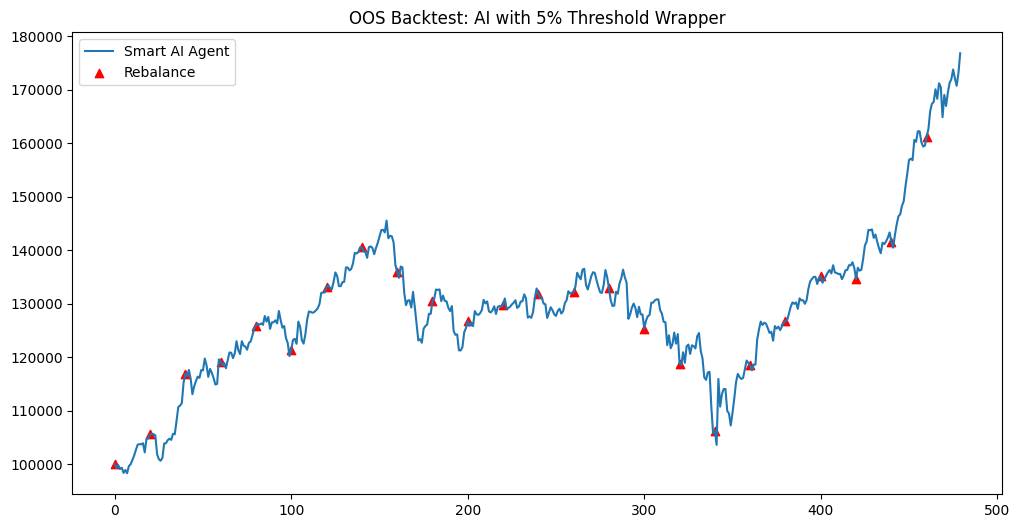

Total Return: 76.71%
Trades Executed: 24


In [6]:
# Run Backtest on TEST Data
test_env = PortfolioRebalanceEnv(price_test, feat_test, bench_test)
# 1. Rerun Backtest with new logger
REBALANCE_THRESHOLD = 0.05
from rl_system import SmartBacktesterWithWeights
backtester = SmartBacktesterWithWeights(model, test_env, threshold=REBALANCE_THRESHOLD)
results = backtester.run()

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(results['nav'], label='Smart AI Agent')

# Plot Trade Markers
trades = results[results['action'] == 'TRADE']
plt.scatter(trades.index, trades['nav'], color='red', marker='^', label='Rebalance')

plt.title("OOS Backtest: AI with 5% Threshold Wrapper")
plt.legend()
plt.show()

# Stats
start_val = results['nav'].iloc[0]
end_val = results['nav'].iloc[-1]
roi = (end_val / start_val) - 1
print(f"Total Return: {roi*100:.2f}%")
print(f"Trades Executed: {len(trades)}")

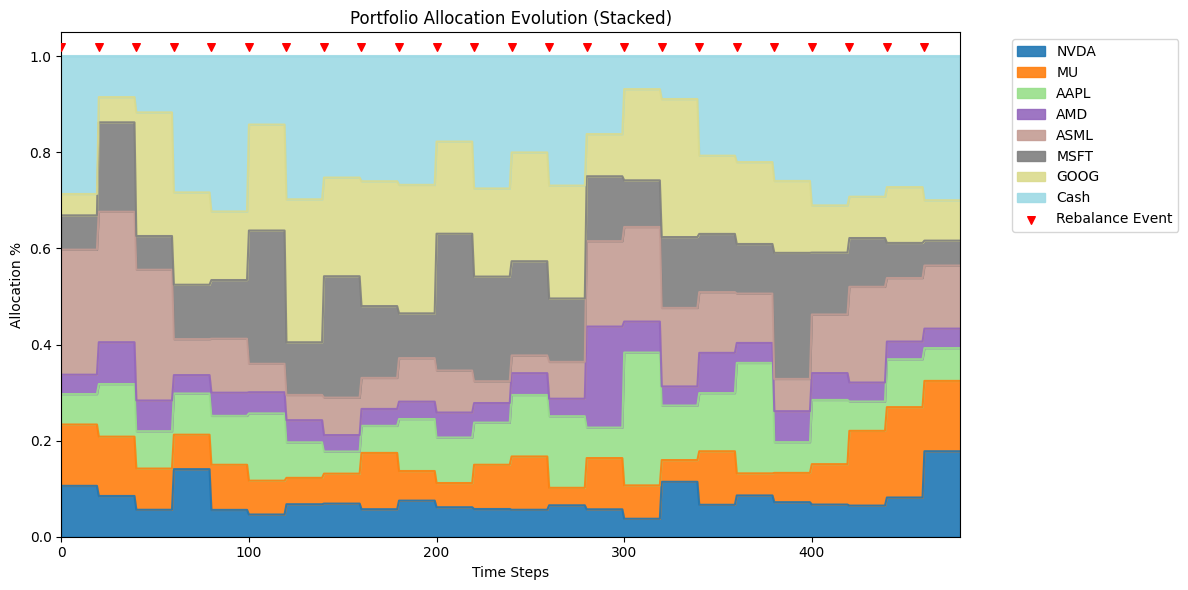

In [7]:
# 2. Process Weights Data
# Expand the 'weights' column (list of arrays) into a proper DataFrame
weight_cols = list(df_full.columns[:-1]) + ['Cash'] # Assets + Cash
weights_df = pd.DataFrame(results['weights'].tolist(), index=results.index, columns=weight_cols)

# 3. Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Use a Stacked Area Plot
weights_df.plot.area(ax=ax, cmap='tab20', alpha=0.9)

# Overlay the Rebalance Points (Red Triangles)
# We plot them at y=1.05 (just above the chart) to see WHEN it acted
rebalance_indices = results[results['action'] == 'TRADE'].index
ax.scatter(rebalance_indices, [1.02]*len(rebalance_indices), 
           color='red', marker='v', s=30, label='Rebalance Event', zorder=10)

plt.title("Portfolio Allocation Evolution (Stacked)")
plt.ylabel("Allocation %")
plt.xlabel("Time Steps")
plt.margins(0, 0) # Remove white space on sides
plt.ylim(0, 1.05) # Give space for the markers
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.tight_layout()
plt.show()